In [1]:
import model2_free_text_chunked_pipeline_v3 as m2fc3

In [2]:
train_df, test_df = m2fc3.prepare_train_test_data(
    "free-text.csv",
    "free-text_synthetic_realistic.csv",
    chunk_size=50,
    test_size=0.2,
    random_state=42
)

Real raw shape: (562583, 9)
Synthetic raw shape: (562583, 9)

Real train chunks shape: (8889, 19)
Real test chunks shape: (2264, 19)
Synthetic train chunks shape: (8889, 19)
Synthetic test chunks shape: (2264, 19)

Final train shape: (17778, 19)
Final test shape: (4528, 19)

Train class counts:
label
1    8889
0    8889
Name: count, dtype: int64

Test class counts:
label
1    2264
0    2264
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = m2fc3.preprocess_train_test(train_df, test_df)


Dropping columns: ['participant', 'session', 'chunk_id']

X_train shape: (17778, 15)
X_test shape: (4528, 15)


In [4]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())
print(X_train.columns)

(17778, 15) (4528, 15)
label
1    8889
0    8889
Name: count, dtype: int64
label
1    2264
0    2264
Name: count, dtype: int64
Index(['DU_hold_mean', 'DU_hold_std', 'DD_mean', 'DD_std', 'DU_flight_mean',
       'DU_flight_std', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std',
       'total_events', 'total_time', 'avg_time_per_event', 'overall_mean',
       'overall_std'],
      dtype='object')


In [5]:
X_train_mi, X_test_mi, mi_features, mi_scores = m2fc3.select_mutual_info(
    X_train, y_train, X_test, k=10
)
X_train_mi_scaled, X_test_mi_scaled = m2fc3.scale_data(X_train_mi, X_test_mi)
mi_results = m2fc3.evaluate_models(X_train_mi_scaled, X_test_mi_scaled, y_train, y_test)


Top Mutual Information Features:
               Feature     Score
12  avg_time_per_event  0.039412
11          total_time  0.038958
2              DD_mean  0.038852
3               DD_std  0.034208
9               UU_std  0.033503
5        DU_flight_std  0.032839
7               UD_std  0.032742
1          DU_hold_std  0.023657
8              UU_mean  0.019902
13        overall_mean  0.018813

Model: Logistic Regression
Accuracy: 0.588560070671378

Confusion Matrix:
[[2082  182]
 [1681  583]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.92      0.69      2264
           1       0.76      0.26      0.38      2264

    accuracy                           0.59      4528
   macro avg       0.66      0.59      0.54      4528
weighted avg       0.66      0.59      0.54      4528

ROC-AUC: 0.6347988643883679

Model: Linear SVM
Accuracy: 0.5777385159010601

Confusion Matrix:
[[1853  411]
 [1501  763]]

Classification Report:
    

In [6]:
X_train_anova, X_test_anova, anova_features, anova_scores = m2fc3.select_anova(
    X_train, y_train, X_test, k=10
)
X_train_anova_scaled, X_test_anova_scaled = m2fc3.scale_data(X_train_anova, X_test_anova)
anova_results = m2fc3.evaluate_models(X_train_anova_scaled, X_test_anova_scaled, y_train, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [10] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Top ANOVA Features:
               Feature      Score       P_Value
5        DU_flight_std  96.605179  9.671072e-23
7               UD_std  81.299595  2.132847e-19
4       DU_flight_mean  73.334044  1.182810e-17
14         overall_std  64.738560  9.086826e-16
13        overall_mean  57.478850  3.584196e-14
3               DD_std  32.006332  1.560367e-08
0         DU_hold_mean  31.149801  2.423513e-08
1          DU_hold_std  29.338497  6.156566e-08
11          total_time  20.755904  5.251739e-06
12  avg_time_per_event  20.755904  5.251739e-06

Model: Logistic Regression
Accuracy: 0.5607332155477032

Confusion Matrix:
[[1500  764]
 [1225 1039]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.66      0.60      2264
           1       0.58      0.46      0.51      2264

    accuracy                           0.56      4528
   macro avg       0.56      0.56      0.56      4528
weighted avg       0.56      0.56      0.56      452

In [7]:
X_train_corr, X_test_corr, corr_features, corr_scores = m2fc3.select_correlation(
    X_train, y_train, X_test, k=10
)
X_train_corr_scaled, X_test_corr_scaled = m2fc3.scale_data(X_train_corr, X_test_corr)
corr_results = m2fc3.evaluate_models(X_train_corr_scaled, X_test_corr_scaled, y_train, y_test)


Top Correlation Features:
              Feature     Score
0       DU_flight_std  0.073520
1              UD_std  0.067474
2      DU_flight_mean  0.064098
3         overall_std  0.060239
4        overall_mean  0.056772
5              DD_std  0.042395
6        DU_hold_mean  0.041824
7         DU_hold_std  0.040592
8             DD_mean  0.034151
9  avg_time_per_event  0.034151

Model: Logistic Regression
Accuracy: 0.5607332155477032

Confusion Matrix:
[[1500  764]
 [1225 1039]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.66      0.60      2264
           1       0.58      0.46      0.51      2264

    accuracy                           0.56      4528
   macro avg       0.56      0.56      0.56      4528
weighted avg       0.56      0.56      0.56      4528

ROC-AUC: 0.606369164304711

Model: Linear SVM
Accuracy: 0.5631625441696113

Confusion Matrix:
[[1448  816]
 [1162 1102]]

Classification Report:
              precisio

In [8]:
X_train_var, X_test_var, var_features, var_scores = m2fc3.select_variance(
    X_train, X_test, threshold=0.0, k=10
)
X_train_var_scaled, X_test_var_scaled = m2fc3.scale_data(X_train_var, X_test_var)
var_results = m2fc3.evaluate_models(X_train_var_scaled, X_test_var_scaled, y_train, y_test)


Top Variance Features:
          Feature      Score
0      total_time  56.843891
1          DD_std   3.257157
2   DU_flight_std   1.798293
3          UD_std   1.730071
4     DU_hold_std   1.472378
5  DU_flight_mean   0.068341
6         UD_mean   0.056062
7          UU_std   0.053899
8    DU_hold_mean   0.051294
9     overall_std   0.030531

Model: Logistic Regression
Accuracy: 0.5898851590106007

Confusion Matrix:
[[2029  235]
 [1622  642]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.90      0.69      2264
           1       0.73      0.28      0.41      2264

    accuracy                           0.59      4528
   macro avg       0.64      0.59      0.55      4528
weighted avg       0.64      0.59      0.55      4528

ROC-AUC: 0.636167068823434

Model: Linear SVM
Accuracy: 0.5784010600706714

Confusion Matrix:
[[1903  361]
 [1548  716]]

Classification Report:
              precision    recall  f1-score   support

   

In [9]:
X_train_md, X_test_md, md_features, md_scores = m2fc3.select_mean_difference(
    X_train, y_train, X_test, k=10
)
X_train_md_scaled, X_test_md_scaled = m2fc3.scale_data(X_train_md, X_test_md)
md_results = m2fc3.evaluate_models(X_train_md_scaled, X_test_md_scaled, y_train, y_test)


Top Mean Difference Features:
          Feature     Score
0      total_time  0.514944
1   DU_flight_std  0.197176
2          UD_std  0.177495
3          DD_std  0.153020
4     DU_hold_std  0.098508
5  DU_flight_mean  0.033512
6     overall_std  0.021051
7    DU_hold_mean  0.018944
8          UU_std  0.015362
9    overall_mean  0.012608

Model: Logistic Regression
Accuracy: 0.5874558303886925

Confusion Matrix:
[[2000  264]
 [1604  660]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.88      0.68      2264
           1       0.71      0.29      0.41      2264

    accuracy                           0.59      4528
   macro avg       0.63      0.59      0.55      4528
weighted avg       0.63      0.59      0.55      4528

ROC-AUC: 0.6362878329108866

Model: Linear SVM
Accuracy: 0.5768551236749117

Confusion Matrix:
[[1859  405]
 [1511  753]]

Classification Report:
              precision    recall  f1-score   support

      

In [10]:
X_train_rfe_lr, X_test_rfe_lr, rfe_lr_features = m2fc3.select_rfe_lr(
    X_train, y_train, X_test, k=10
)
X_train_rfe_lr_scaled, X_test_rfe_lr_scaled = m2fc3.scale_data(X_train_rfe_lr, X_test_rfe_lr)
rfe_lr_results = m2fc3.evaluate_models(X_train_rfe_lr_scaled, X_test_rfe_lr_scaled, y_train, y_test)


RFE Logistic Regression Features:
['DU_hold_mean', 'DU_hold_std', 'DD_std', 'DU_flight_std', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std', 'overall_mean', 'overall_std']

Model: Logistic Regression
Accuracy: 0.5916519434628975

Confusion Matrix:
[[2027  237]
 [1612  652]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.90      0.69      2264
           1       0.73      0.29      0.41      2264

    accuracy                           0.59      4528
   macro avg       0.65      0.59      0.55      4528
weighted avg       0.65      0.59      0.55      4528

ROC-AUC: 0.6374870846807927

Model: Linear SVM
Accuracy: 0.5781802120141343

Confusion Matrix:
[[1894  370]
 [1540  724]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.84      0.66      2264
           1       0.66      0.32      0.43      2264

    accuracy                           0.58      4528
   macro avg   

In [11]:
X_train_rfe_svm, X_test_rfe_svm, rfe_svm_features = m2fc3.select_rfe_svm(
    X_train, y_train, X_test, k=10
)
X_train_rfe_svm_scaled, X_test_rfe_svm_scaled = m2fc3.scale_data(X_train_rfe_svm, X_test_rfe_svm)
rfe_svm_results = m2fc3.evaluate_models(X_train_rfe_svm_scaled, X_test_rfe_svm_scaled, y_train, y_test)


RFE Linear SVM Features:
['DU_hold_mean', 'DU_hold_std', 'DD_std', 'DU_flight_mean', 'DU_flight_std', 'UD_std', 'UU_mean', 'UU_std', 'overall_mean', 'overall_std']

Model: Logistic Regression
Accuracy: 0.5909893992932862

Confusion Matrix:
[[2022  242]
 [1610  654]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.89      0.69      2264
           1       0.73      0.29      0.41      2264

    accuracy                           0.59      4528
   macro avg       0.64      0.59      0.55      4528
weighted avg       0.64      0.59      0.55      4528

ROC-AUC: 0.6370924065726878

Model: Linear SVM
Accuracy: 0.5792844522968198

Confusion Matrix:
[[1881  383]
 [1522  742]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.83      0.66      2264
           1       0.66      0.33      0.44      2264

    accuracy                           0.58      4528
   macro avg     

In [12]:
X_train_rfe_rf, X_test_rfe_rf, rfe_rf_features = m2fc3.select_rfe_rf(
    X_train, y_train, X_test, k=10
)
X_train_rfe_rf_scaled, X_test_rfe_rf_scaled = m2fc3.scale_data(X_train_rfe_rf, X_test_rfe_rf)
rfe_rf_results = m2fc3.evaluate_models(X_train_rfe_rf_scaled, X_test_rfe_rf_scaled, y_train, y_test)


RFE Random Forest Features:
['DU_hold_std', 'DD_mean', 'DD_std', 'DU_flight_std', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std', 'total_time', 'avg_time_per_event']

Model: Logistic Regression
Accuracy: 0.5894434628975265

Confusion Matrix:
[[2079  185]
 [1674  590]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.92      0.69      2264
           1       0.76      0.26      0.39      2264

    accuracy                           0.59      4528
   macro avg       0.66      0.59      0.54      4528
weighted avg       0.66      0.59      0.54      4528

ROC-AUC: 0.6349783522081685

Model: Linear SVM
Accuracy: 0.5779593639575972

Confusion Matrix:
[[1883  381]
 [1530  734]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.83      0.66      2264
           1       0.66      0.32      0.43      2264

    accuracy                           0.58      4528
   macro avg       0.

In [13]:
X_train_sfm_lr, X_test_sfm_lr, sfm_lr_features, sfm_lr_scores = m2fc3.select_sfm_lr(
    X_train, y_train, X_test, k=10
)
X_train_sfm_lr_scaled, X_test_sfm_lr_scaled = m2fc3.scale_data(X_train_sfm_lr, X_test_sfm_lr)
sfm_lr_results = m2fc3.evaluate_models(X_train_sfm_lr_scaled, X_test_sfm_lr_scaled, y_train, y_test)


SelectFromModel Logistic Regression Features:
           Feature     Score
5    DU_flight_std  4.523599
9           UU_std  3.894940
3           DD_std  3.703596
7           UD_std  2.902368
1      DU_hold_std  1.620031
0     DU_hold_mean  0.510707
11      total_time  0.015203
10    total_events  0.000510
2          DD_mean  0.000000
4   DU_flight_mean  0.000000

Model: Logistic Regression
Accuracy: 0.5870141342756183

Confusion Matrix:
[[2031  233]
 [1637  627]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.90      0.68      2264
           1       0.73      0.28      0.40      2264

    accuracy                           0.59      4528
   macro avg       0.64      0.59      0.54      4528
weighted avg       0.64      0.59      0.54      4528

ROC-AUC: 0.6350671206407871

Model: Linear SVM
Accuracy: 0.5790636042402827

Confusion Matrix:
[[1865  399]
 [1507  757]]

Classification Report:
              precision    recall 

In [14]:
X_train_sfm_rf, X_test_sfm_rf, sfm_rf_features, sfm_rf_scores = m2fc3.select_sfm_rf(
    X_train, y_train, X_test, k=10
)
X_train_sfm_rf_scaled, X_test_sfm_rf_scaled = m2fc3.scale_data(X_train_sfm_rf, X_test_sfm_rf)
sfm_rf_results = m2fc3.evaluate_models(X_train_sfm_rf_scaled, X_test_sfm_rf_scaled, y_train, y_test)


SelectFromModel Random Forest Features:
               Feature     Score
2              DD_mean  0.133895
12  avg_time_per_event  0.133512
1          DU_hold_std  0.118321
3               DD_std  0.105806
7               UD_std  0.101836
11          total_time  0.095508
9               UU_std  0.077476
5        DU_flight_std  0.076812
6              UD_mean  0.057191
8              UU_mean  0.033069

Model: Logistic Regression
Accuracy: 0.5894434628975265

Confusion Matrix:
[[2079  185]
 [1674  590]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.92      0.69      2264
           1       0.76      0.26      0.39      2264

    accuracy                           0.59      4528
   macro avg       0.66      0.59      0.54      4528
weighted avg       0.66      0.59      0.54      4528

ROC-AUC: 0.6349783522081685

Model: Linear SVM
Accuracy: 0.5779593639575972

Confusion Matrix:
[[1883  381]
 [1530  734]]

Classification Repo

In [15]:
print("MI best:\n", mi_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nANOVA best:\n", anova_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nCorrelation best:\n", corr_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nVariance best:\n", var_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nMean Difference best:\n", md_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nRFE LR best:\n", rfe_lr_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nRFE SVM best:\n", rfe_svm_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nRFE RF best:\n", rfe_rf_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nSFM LR best:\n", sfm_lr_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nSFM RF best:\n", sfm_rf_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])

MI best:
 Model       Random Forest
Accuracy         0.621908
ROC_AUC           0.69811
Name: 2, dtype: object

ANOVA best:
 Model       Random Forest
Accuracy         0.621687
ROC_AUC          0.695141
Name: 2, dtype: object

Correlation best:
 Model       Random Forest
Accuracy         0.621687
ROC_AUC          0.695141
Name: 2, dtype: object

Variance best:
 Model       Random Forest
Accuracy         0.631846
ROC_AUC           0.70846
Name: 2, dtype: object

Mean Difference best:
 Model       Random Forest
Accuracy         0.628534
ROC_AUC          0.708532
Name: 2, dtype: object

RFE LR best:
 Model       Decision Tree
Accuracy         0.619258
ROC_AUC          0.669792
Name: 4, dtype: object

RFE SVM best:
 Model       Random Forest
Accuracy          0.61462
ROC_AUC            0.6896
Name: 2, dtype: object

RFE RF best:
 Model       Random Forest
Accuracy         0.626104
ROC_AUC          0.700525
Name: 2, dtype: object

SFM LR best:
 Model       Random Forest
Accuracy         0.6

In [16]:
summary_df = m2fc3.feature_selection_summary(
    mi_features,
    anova_features,
    corr_features,
    var_features,
    md_features,
    rfe_lr_features,
    rfe_svm_features,
    rfe_rf_features,
    sfm_lr_features,
    sfm_rf_features
)

summary_df.head(15)


Feature Selection Summary:
               Feature  Times_Selected
3               DD_std              10
5        DU_flight_std              10
6               UD_std              10
7          DU_hold_std              10
4               UU_std               8
1           total_time               7
12        DU_hold_mean               7
9         overall_mean               6
10      DU_flight_mean               6
11         overall_std               6
0   avg_time_per_event               5
2              DD_mean               5
8              UU_mean               5
13             UD_mean               4
14        total_events               1


,Feature,Times_Selected
3,DD_std,10
5,DU_flight_std,10
6,UD_std,10
7,DU_hold_std,10
4,UU_std,8
1,total_time,7
12,DU_hold_mean,7
9,overall_mean,6
10,DU_flight_mean,6
11,overall_std,6


In [17]:
best_model = m2fc3.get_models()["Random Forest"]

X_train_best, X_test_best, _ = m2fc3.select_sfm_rf(
    X_train, y_train, X_test, k=10
)

X_train_best_scaled, X_test_best_scaled = m2fc3.scale_data(
    X_train_best, X_test_best
)

best_model.fit(X_train_best_scaled, y_train)

y_pred_best = best_model.predict(X_test_best_scaled)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best)

print("Best Model: Random Forest")
print("Accuracy:", (y_pred_best == y_test).mean())
print("Confusion Matrix:\n", cm)


SelectFromModel Random Forest Features:
               Feature     Score
2              DD_mean  0.133895
12  avg_time_per_event  0.133512
1          DU_hold_std  0.118321
3               DD_std  0.105806
7               UD_std  0.101836
11          total_time  0.095508
9               UU_std  0.077476
5        DU_flight_std  0.076812
6              UD_mean  0.057191
8              UU_mean  0.033069


ValueError: too many values to unpack (expected 3)

In [18]:
m2fc3.plot_confusion_matrix(cm, title="Modal 2 - Random Forest Confusion Matrix")

NameError: name 'cm' is not defined

In [19]:
best_model = m2fc3.get_models()["Random Forest"]

X_train_best, X_test_best, selected_features, score_df = m2fc3.select_sfm_rf(
    X_train, y_train, X_test, k=10
)

X_train_best_scaled, X_test_best_scaled = m2fc3.scale_data(
    X_train_best, X_test_best
)

best_model.fit(X_train_best_scaled, y_train)

y_pred_best = best_model.predict(X_test_best_scaled)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best)

print("Best Model: Random Forest")
print("Accuracy:", (y_pred_best == y_test).mean())
print("Confusion Matrix:\n", cm)


SelectFromModel Random Forest Features:
               Feature     Score
2              DD_mean  0.133895
12  avg_time_per_event  0.133512
1          DU_hold_std  0.118321
3               DD_std  0.105806
7               UD_std  0.101836
11          total_time  0.095508
9               UU_std  0.077476
5        DU_flight_std  0.076812
6              UD_mean  0.057191
8              UU_mean  0.033069
Best Model: Random Forest
Accuracy: 0.6327296819787986
Confusion Matrix:
 [[1054 1210]
 [ 453 1811]]


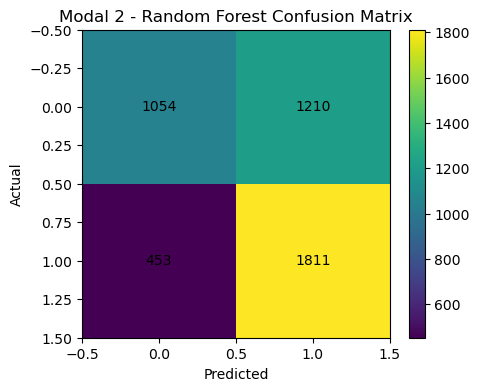

In [20]:
m2fc3.plot_confusion_matrix(cm, title="Modal 2 - Random Forest Confusion Matrix")

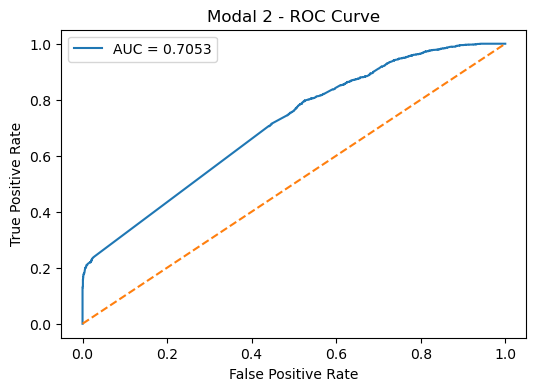

In [21]:
m2fc3.plot_roc(
    best_model,
    X_test_best_scaled,
    y_test,
    title="Modal 2 - ROC Curve"
)